[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\russm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



📊 Classification Report (Without Feature Selection):
              precision    recall  f1-score   support

           0       0.36      0.48      0.41        42
           1       0.06      0.01      0.02       107
           2       0.72      0.69      0.70      1209
           3       0.50      0.61      0.55       632
           4       0.00      0.00      0.00        10

    accuracy                           0.62      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.60      0.62      0.61      2000

🧾 Confusion Matrix for CNB (No Feature Selection):
 [[ 20   0   9  13   0]
 [  8   1  74  24   0]
 [ 19  11 833 346   0]
 [  6   3 239 384   0]
 [  2   1   3   4   0]]


c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

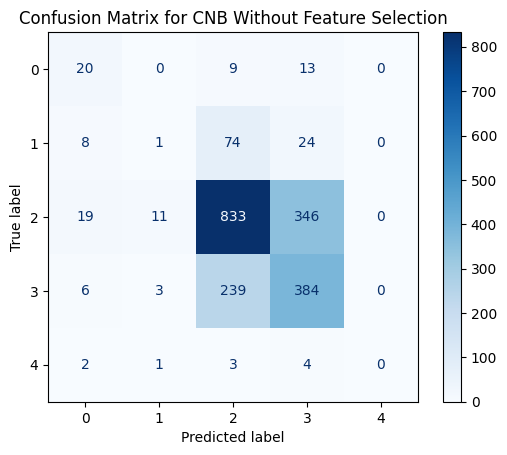

 FORWARD SELECTION STARTED
Added: tfidf (F1 = 0.2758)
Added: year (F1 = 0.3233)
Added: genres (F1 = 0.3346)
 No improvement — stopping selection.

 Final selected features: ['tfidf', 'year', 'genres']

 Classification Report (Forward Selection):
              precision    recall  f1-score   support

           0       0.36      0.50      0.42        42
           1       0.06      0.01      0.02       107
           2       0.72      0.69      0.71      1209
           3       0.50      0.61      0.55       632
           4       0.00      0.00      0.00        10

    accuracy                           0.62      2000
   macro avg       0.33      0.36      0.34      2000
weighted avg       0.61      0.62      0.61      2000

🧾 Confusion Matrix For CNB:
 [[ 21   0   8  13   0]
 [ 10   1  73  23   0]
 [ 20  12 834 343   0]
 [  6   3 238 385   0]
 [  2   1   3   4   0]]


c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\russm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

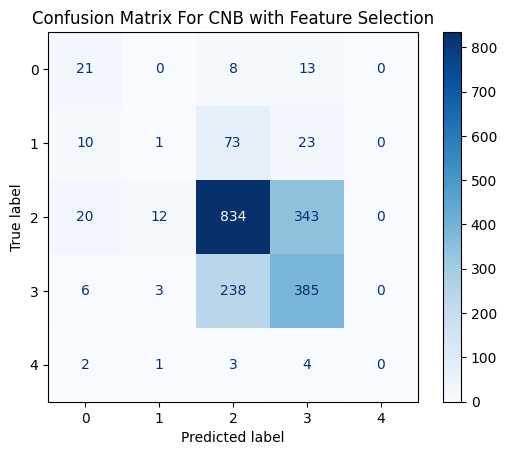

In [ ]:
############################################################

# COMPLEMENT NAIVE BAYES CODE

# Students: Russ Mehta (501177625) Joseph Carvalho (501162291)


################################################################

import numpy as np
import pandas as pd
import string
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import hstack, csr_matrix
import nltk
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# Downloads (comment out if already done)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('./imdb_movies.csv')
df = df[df['orig_lang'].apply(lambda x: x.isascii())]
df = df.drop_duplicates(subset=['names', 'date_x'])
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)

df['budget_x'] = pd.to_numeric(df['budget_x'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['budget_normalized'] = MinMaxScaler().fit_transform(df[['budget_x']].fillna(0))
df['revenue_normalized'] = MinMaxScaler().fit_transform(df[['revenue']].fillna(0))

df['genre_list'] = df['genre'].fillna('').apply(lambda x: [g.strip() for g in x.split(',')])


def map_rating(score):
    if pd.isna(score): return np.nan
    score = float(score)
    if score < 30:
        return 0
    elif score < 50:
        return 1
    elif score < 70:
        return 2
    elif score < 85:
        return 3
    else:
        return 4


df['rating_class'] = df['score'].apply(map_rating)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text: str):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = ''.join([char for char in text if char.isascii() and char not in string.punctuation])
    tokens = word_tokenize(text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(lemmatized)


df['clean_overview'] = df['overview'].apply(clean_text)

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_overview'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df['genre_list'])
genre_sparse = csr_matrix(genre_matrix)

budget_sparse = csr_matrix(df[['budget_normalized']].fillna(0).values)
revenue_sparse = csr_matrix(df[['revenue_normalized']].fillna(0).values)

df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(0).astype(int)
year_encoded = pd.get_dummies(df['release_year'], prefix='year')
year_sparse = csr_matrix(year_encoded.values)

valid_rows = df['rating_class'].notna().to_numpy()
df_valid = df.loc[valid_rows].reset_index(drop=True)

X_tfidf_valid = X_tfidf[valid_rows]
genre_sparse_valid = genre_sparse[valid_rows]
budget_sparse_valid = budget_sparse[valid_rows]
revenue_sparse_valid = revenue_sparse[valid_rows]
year_sparse_valid = year_sparse[valid_rows]

y = df_valid['rating_class']


# === FORWARD SELECTION ===

# 2. Stack all features into one matrix
X = hstack([
    X_tfidf_valid,
    genre_sparse_valid,
    budget_sparse_valid,
    revenue_sparse_valid,
    year_sparse_valid
])


# Use the full feature set (before selection)
# Replace X_full_combined with your full feature matrix variable (e.g., X_combined)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the CNB model
model = OneVsRestClassifier(ComplementNB())
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Print classification report
print("\n📊 Classification Report (Without Feature Selection):")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("🧾 Confusion Matrix for CNB (No Feature Selection):\n", cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for CNB Without Feature Selection")
plt.show()


feature_blocks = {
    'tfidf': X_tfidf_valid,
    'genres': genre_sparse_valid,
    'budget': budget_sparse_valid,
    'revenue': revenue_sparse_valid,
    'year': year_sparse_valid
}

selected = []
remaining = list(feature_blocks.keys())
best_score = 0
from sklearn.naive_bayes import ComplementNB

print(" FORWARD SELECTION STARTED")
while remaining:
    scores = []
    for feat in remaining:
        X_try = hstack([feature_blocks[f] for f in selected + [feat]])
        score = cross_val_score(
            OneVsRestClassifier(ComplementNB()),
            X_try, y, cv=3, scoring='f1_macro'
        ).mean()
        scores.append((feat, score))

    best_feat, best_feat_score = max(scores, key=lambda x: x[1])
    if best_feat_score > best_score:
        selected.append(best_feat)
        remaining.remove(best_feat)
        best_score = best_feat_score
        print(f"Added: {best_feat} (F1 = {best_feat_score:.4f})")
    else:
        print(" No improvement — stopping selection.")
        break

print(f"\n Final selected features: {selected}")

X_selected = hstack([feature_blocks[f] for f in selected])
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import ComplementNB

model = OneVsRestClassifier(ComplementNB())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n Classification Report (Forward Selection):")
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming it's a single-label multi-class task (not multilabel)
cm = confusion_matrix(y_test, y_pred)
print("🧾 Confusion Matrix For CNB:\n", cm)

# Optional: display with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix For CNB with Feature Selection")
plt.show()


In [ ]:
#